# **Transporter promiscuity analysis**

In [67]:
import harreman
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from scipy.stats import spearmanr, pearsonr, gaussian_kde
import torch
from scipy.sparse import issparse
from harreman.hotspot import models
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from plotnine import *
import warnings
warnings.filterwarnings("ignore")

## Functions

In [2]:
def compute_metabolite_cs(
    cs_gp: torch.Tensor,
    gene_pair_dict: dict,
    interacting_cell_scores: bool = False
) -> torch.Tensor:
    """
    Computes metabolite-level communication scores from gene-pair scores.

    Parameters
    ----------
    cs_gp : torch.Tensor
        - If interacting_cell_scores is False: shape (gene_pairs,)
        - If interacting_cell_scores is True: shape (cells, gene_pairs)
    gene_pair_dict : dict
        Maps metabolite names to a list of indices (ints) referring to gene-pairs.
    interacting_cell_scores : bool, optional
        Whether cs_gp contains per-cell scores.

    Returns
    -------
    cs_m : torch.Tensor
        - If interacting_cell_scores is False: shape (num_metabolites,)
        - If interacting_cell_scores is True: shape (cells, num_metabolites)
    """
    device = cs_gp.device
    scores = []

    for indices in gene_pair_dict.values():
        idx_tensor = torch.tensor(indices, device=device, dtype=torch.long)
        if interacting_cell_scores:
            summed = cs_gp[:, idx_tensor].sum(dim=1)  # shape: (cells,)
        else:
            summed = cs_gp[idx_tensor].sum()          # scalar
        scores.append(summed)

    if interacting_cell_scores:
        cs_m = torch.stack(scores, dim=1)  # shape: (cells, metabolites)
    else:
        cs_m = torch.stack(scores)        # shape: (metabolites,)
    
    return cs_m

In [3]:
def make_weights_non_redundant(weights):

    w_no_redundant = weights.copy()
    
    rows, cols = w_no_redundant.nonzero()
    upper_diag_mask = rows < cols
    upper_rows, upper_cols = rows[upper_diag_mask], cols[upper_diag_mask]

    w_no_redundant[upper_rows, upper_cols] += w_no_redundant[upper_cols, upper_rows]
    w_no_redundant[upper_cols, upper_rows] = 0
    w_no_redundant.eliminate_zeros()

    return w_no_redundant

In [4]:
def center_counts_torch(counts, num_umi, model):
    """
    counts: Tensor [genes, cells]
    num_umi: Tensor [cells]
    model: 'bernoulli', 'danb', 'normal', or 'none'
    
    Returns:
        Centered counts: Tensor [genes, cells]
    """
    # Binarize if using Bernoulli
    if model == 'bernoulli':
        counts = (counts > 0).double()
        mu, var, _ = models.bernoulli_model_torch(counts, num_umi)
    elif model == 'danb':
        mu, var, _ = models.danb_model_torch(counts, num_umi)
    elif model == 'normal':
        mu, var, _ = models.normal_model_torch(counts, num_umi)
    elif model == 'none':
        mu, var, _ = models.none_model_torch(counts, num_umi)
    else:
        raise ValueError(f"Unsupported model type: {model}")
    
    # Avoid division by zero
    std = torch.sqrt(var)
    std[std == 0] = 1.0

    centered = (counts - mu) / std
    centered[centered == 0] = 0  # Optional: to match old behavior
    
    return centered

In [5]:
def standardize_counts(adata, counts, model, num_umi, sample_specific):
    
    if sample_specific:
        sample_key = adata.uns['sample_key']
        for sample in adata.obs[sample_key].unique():
            subset = np.where(adata.obs[sample_key] == sample)[0]
            counts[:, subset] = center_counts_torch(counts[:, subset], num_umi[subset], model)
    else:
        counts = center_counts_torch(counts, num_umi, model)
    
    return counts

In [6]:
def counts_from_anndata(adata, layer_key=None, dense=False):
    # 1. Extract matrix
    if layer_key is None:
        counts = adata.X
    elif layer_key == "use_raw":
        counts = adata.raw.X
    else:
        counts = adata.layers[layer_key]

    # 2. Transpose efficiently
    if issparse(counts):
        counts = counts.transpose().tocsr(copy=False)  # keep CSR format for efficient row slicing
    else:
        counts = counts.T  # transpose numpy array directly

    # 3. Convert to dense if requested
    if dense:
        if issparse(counts):
            counts = counts.toarray()
        else:
            counts = np.asarray(counts)

    return counts

In [7]:
def flatten(nested_list):
    for item in nested_list:
        if isinstance(item, (list, tuple)):
            yield from flatten(item)
        else:
            yield item

In [8]:
# --------------------------------------------------
# 1. Utilities
# --------------------------------------------------

def flatten_gene_pair(gene_pair):
    """
    Converts a gene_pair tuple into a flat list of transporters.

    Input examples:
        ("SLC6A8", "SLC6A8")
        (["SLC3A1", "SLC7A9"], "SLC6A8")

    Output:
        ["SLC3A1", "SLC7A9", "SLC6A8"]
    """
    if gene_pair is None:
        return []

    genes = []

    for elem in gene_pair:
        if isinstance(elem, list):
            genes.extend(elem)
        else:
            genes.append(elem)

    # remove None / nan
    genes = [g for g in genes if pd.notna(g)]

    return list(set(genes))  # unique transporters

def add_transporter_columns(df, gene_pair_col="gene_pair"):
    """
    Add parsed transporter columns:
      - transporter_list
      - unique_transporters_per_pair
    """
    df = df.copy()
    df["unique_transporters_per_pair"] = df[gene_pair_col].apply(flatten_gene_pair)
    return df

In [9]:
# --------------------------------------------------
# 2. Coverage / promiscuity metrics
# --------------------------------------------------

def compute_transporter_degrees(df, metabolite_col="metabolite"):
    """
    Compute transporter degree:
    how many unique metabolites each transporter is associated with.
    """
    exploded = df[[metabolite_col, "unique_transporters_per_pair"]].explode("unique_transporters_per_pair")
    exploded = exploded.rename(columns={"unique_transporters_per_pair": "transporter"})
    exploded = exploded.dropna()

    transporter_degree = (
        exploded.groupby("transporter")[metabolite_col]
        .nunique()
        .rename("transporter_degree")
        .reset_index()
    )
    return transporter_degree


def compute_metabolite_coverage_metrics(
    df,
    metabolite_col="metabolite",
    gene_pair_col="gene_pair"
):
    """
    Compute per-metabolite coverage metrics:
      - n_gene_pairs
      - n_unique_transporters
      - mean / median transporter degree
      - max transporter degree
    """
    transporter_degree = compute_transporter_degrees(df, metabolite_col=metabolite_col)

    exploded = df[[metabolite_col, gene_pair_col, "unique_transporters_per_pair"]].explode("unique_transporters_per_pair")
    exploded = exploded.rename(columns={"unique_transporters_per_pair": "transporter"})
    exploded = exploded.dropna()
    exploded = exploded.merge(transporter_degree, on="transporter", how="left")

    n_gene_pairs = (
        df.groupby(metabolite_col)[gene_pair_col]
        .nunique()
        .rename("n_gene_pairs")
    )

    n_unique_transporters = (
        exploded.groupby(metabolite_col)["transporter"]
        .nunique()
        .rename("n_unique_transporters")
    )

    promiscuity_stats = (
        exploded.groupby(metabolite_col)["transporter_degree"]
        .agg(
            mean_transporter_degree="mean",
            median_transporter_degree="median",
            max_transporter_degree="max"
        )
    )

    out = pd.concat([n_gene_pairs, n_unique_transporters, promiscuity_stats], axis=1).reset_index()
    return out

In [10]:
def compute_gene_pair_core(
    adata,
    layer_key_p_test=None,
    layer_key_np_test=None,
    model=None,
    subset_gene_pairs=None,
    mean='algebraic',
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
):
    use_raw = (layer_key_p_test == "use_raw") & (layer_key_np_test == "use_raw")
    cells = adata.raw.obs.index.values.astype(str) if use_raw else adata.obs_names.values.astype(str)
    sample_specific = 'sample_key' in adata.uns

    gene_pairs = adata.uns["gene_pairs"] if subset_gene_pairs is None else subset_gene_pairs
    genes = list(np.unique(list(flatten(adata.uns["gene_pairs"]))))

    gene_pairs_ind = []
    for pair in gene_pairs:
        idx1 = [genes.index(g) for g in pair[0]] if isinstance(pair[0], list) else genes.index(pair[0])
        idx2 = [genes.index(g) for g in pair[1]] if isinstance(pair[1], list) else genes.index(pair[1])
        gene_pairs_ind.append((idx1, idx2))

    weights = make_weights_non_redundant(adata.obsp["weights"]).tocoo()
    weights = torch.sparse_coo_tensor(
        torch.tensor(np.vstack((weights.row, weights.col)), dtype=torch.long, device=device),
        torch.tensor(weights.data, dtype=torch.float64, device=device),
        torch.Size(weights.shape),
        device=device,
    )

    Wtot2 = torch.tensor((weights.data ** 2).sum(), device=device)

    counts = counts_from_anndata(adata[cells, genes], layer_key_p_test, dense=True)
    counts = torch.tensor(counts, dtype=torch.float64, device=device)
    num_umi = counts.sum(dim=0)

    counts_1 = []
    counts_2 = []
    for (idx1, idx2) in gene_pairs_ind:
        if isinstance(idx1, list):
            c1 = counts[idx1, :].mean(dim=0) if mean == 'algebraic' else torch.exp(torch.log(counts[idx1, :] + 1e-8).mean(dim=0))
        else:
            c1 = counts[idx1, :]
        if isinstance(idx2, list):
            c2 = counts[idx2, :].mean(dim=0) if mean == 'algebraic' else torch.exp(torch.log(counts[idx2, :] + 1e-8).mean(dim=0))
        else:
            c2 = counts[idx2, :]
        counts_1.append(c1)
        counts_2.append(c2)

    counts_1 = torch.stack(counts_1)
    counts_2 = torch.stack(counts_2)

    counts_1 = standardize_counts(adata, counts_1, model, num_umi, sample_specific)
    counts_2 = standardize_counts(adata, counts_2, model, num_umi, sample_specific)

    WX2t = torch.sparse.mm(weights, counts_2.T)
    WtX2t = torch.sparse.mm(weights.transpose(0, 1), counts_2.T)
    cs_gp = (counts_1.T * WX2t).sum(0) + (counts_1.T * WtX2t).sum(0)

    same_gene_mask = torch.tensor([g1 == g2 for g1, g2 in gene_pairs], device=device)
    cs_gp[same_gene_mask] = cs_gp[same_gene_mask] / 2

    WX1t = torch.sparse.mm(weights, counts_1.T)
    WtX1t = torch.sparse.mm(weights.transpose(0, 1), counts_1.T)
    eg2_a = (WX1t + WtX1t).pow(2).sum(dim=0)
    eg2_b = (WX2t + WtX2t).pow(2).sum(dim=0)

    same_gene_mask_ind = torch.tensor([
        (isinstance(g1, int) and isinstance(g2, int) and g1 == g2) or
        (isinstance(g1, list) and isinstance(g2, list) and sorted(g1) == sorted(g2))
        for g1, g2 in gene_pairs_ind
    ], device=device)

    EG2_a = eg2_a.clone()
    EG2_b = eg2_b.clone()
    EG2_a[same_gene_mask_ind] = Wtot2
    EG2_b[same_gene_mask_ind] = Wtot2

    z_a = cs_gp / torch.sqrt(torch.where(EG2_a == 0, torch.ones_like(EG2_a), EG2_a))
    z_b = cs_gp / torch.sqrt(torch.where(EG2_b == 0, torch.ones_like(EG2_b), EG2_b))
    use_a = torch.abs(z_a) < torch.abs(z_b)

    EG2_gp = torch.where(use_a, EG2_a, EG2_b)
    Z_gp = torch.where(use_a, z_a, z_b)

    return {
        "gene_pairs": gene_pairs,
        "gene_pairs_ind": gene_pairs_ind,
        "cs_gp": cs_gp,
        "EG2_gp": EG2_gp,
        "Z_gp": Z_gp,
        "Wtot2": Wtot2,
    }

In [11]:
def build_gene_pair_dict(adata, gene_pairs, exclude_LR=False):
    
    gene_pairs_per_metabolite = adata.uns['gene_pairs_per_metabolite']
    
    metabolite_gene_pair_df = pd.DataFrame.from_dict(gene_pairs_per_metabolite, orient="index").reset_index()
    metabolite_gene_pair_df = metabolite_gene_pair_df.rename(columns={"index": "metabolite"})

    metabolite_gene_pair_df['gene_pair'] = metabolite_gene_pair_df['gene_pair'].apply(lambda arr: [(sub_array[0], sub_array[1]) for sub_array in arr])
    metabolite_gene_pair_df['gene_type'] = metabolite_gene_pair_df['gene_type'].apply(lambda arr: [(sub_array[0], sub_array[1]) for sub_array in arr])

    metabolite_gene_pair_df = pd.concat(
        [
            metabolite_gene_pair_df['metabolite'],
            metabolite_gene_pair_df.explode('gene_pair')['gene_pair'],
            metabolite_gene_pair_df.explode('gene_type')['gene_type'],
        ],
        axis=1,
    )
    metabolite_gene_pair_df = metabolite_gene_pair_df.reset_index(drop=True)
    
    if 'LR_database' in adata.uns.keys():
        LR_database = adata.uns['LR_database']
        df_merged = pd.merge(metabolite_gene_pair_df, LR_database, left_on='metabolite', right_on='interaction_name', how='left')
        LR_df = df_merged.dropna(subset=['pathway_name'])
        metabolite_gene_pair_df['metabolite'][metabolite_gene_pair_df.metabolite.isin(LR_df.metabolite)] = LR_df['pathway_name']
    
    if exclude_LR:
        LR_pathways = LR_df['pathway_name'].unique().tolist()
        metabolite_gene_pair_df = metabolite_gene_pair_df[~metabolite_gene_pair_df['metabolite'].isin(LR_pathways)].copy()
    
    gene_pair_dict = {}
    for metabolite, group in metabolite_gene_pair_df.groupby("metabolite"):
        idxs = group["gene_pair"].apply(lambda gp: gene_pairs.index(gp) if gp in gene_pairs else None).dropna().tolist()
        idxs = [int(ind) for ind in idxs if ind is not None]
        if idxs:
            gene_pair_dict[metabolite] = idxs

    return gene_pair_dict

In [12]:
def compute_metabolite_z_from_dict(cs_gp, EG2_gp, gene_pair_dict):
    cs_m = compute_metabolite_cs(cs_gp, gene_pair_dict, interacting_cell_scores=False)
    EG2_m = compute_metabolite_cs(EG2_gp, gene_pair_dict, interacting_cell_scores=False)

    if not isinstance(EG2_m, torch.Tensor):
        EG2_m = torch.tensor(EG2_m, device=cs_gp.device, dtype=torch.float64)

    std_m = torch.sqrt(EG2_m)
    std_m[std_m == 0] = 1.0
    Z_m = cs_m / std_m
    return Z_m

In [13]:
def compute_gene_pair_metab_z_scores(
    adata,
    layer_key_p_test=None,
    layer_key_np_test=None,
    model=None,
    subset_gene_pairs=None,
    mean='algebraic',
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    exclude_LR=False,
    run_subsampling=False,
    run_leave_one_out=False,
    subsample_k=3,
    subsample_iter=100,
    random_state=0,
):

    core = compute_gene_pair_core(
        adata=adata,
        layer_key_p_test=layer_key_p_test,
        layer_key_np_test=layer_key_np_test,
        model=model,
        subset_gene_pairs=subset_gene_pairs,
        mean=mean,
        device=device,
    )

    gene_pairs = core["gene_pairs"]
    cs_gp = core["cs_gp"]
    EG2_gp = core["EG2_gp"]
    Z_gp = core["Z_gp"]

    gene_pair_dict = build_gene_pair_dict(adata, gene_pairs, exclude_LR=exclude_LR)
    metabolites = list(gene_pair_dict.keys())

    Z_m = compute_metabolite_z_from_dict(cs_gp, EG2_gp, gene_pair_dict)

    results = {
        "Z_gp": Z_gp.detach().cpu().numpy(),
        "Z_m": Z_m.detach().cpu().numpy(),
        "metabolites": metabolites,
        "gene_pair_dict": gene_pair_dict,
    }

    # -----------------------------
    # Fast fixed-size subsampling
    # -----------------------------
    if run_subsampling:
        print("Running subsampling analysis...")
        rng = np.random.default_rng(random_state)
        subsample_rows = []

        for it in tqdm(range(subsample_iter)):
            sub_dict = {}
            kept_metabolites = []

            for m, idxs in gene_pair_dict.items():
                if len(idxs) == 0:
                    continue
                if len(idxs) <= subsample_k:
                    continue
                k = min(subsample_k, len(idxs))
                chosen = rng.choice(np.array(idxs), size=k, replace=False)
                chosen = sorted(chosen.tolist())
                if len(chosen) > 0:
                    sub_dict[m] = chosen
                    kept_metabolites.append(m)

            Z_m_sub = compute_metabolite_z_from_dict(cs_gp, EG2_gp, sub_dict).detach().cpu().numpy()

            for j, m in enumerate(kept_metabolites):
                subsample_rows.append({
                    "iteration": it,
                    "metabolite": m,
                    "subsampled_Z_m": Z_m_sub[j],
                    "n_pairs_sampled": len(sub_dict[m]),
                })

        subsample_df = pd.DataFrame(subsample_rows)

        full_df = pd.DataFrame({
            "metabolite": metabolites,
            "full_Z_m": results["Z_m"],
        })

        subsample_summary = (
            subsample_df.groupby("metabolite")
            .agg(
                subsampled_mean=("subsampled_Z_m", "mean"),
                subsampled_std=("subsampled_Z_m", "std"),
                subsampled_n=("subsampled_Z_m", "count"),
                n_pairs_sampled=("n_pairs_sampled", "first"),
            )
            .reset_index()
            .merge(full_df, on="metabolite", how="left")
        )
        
        subsample_summary["subsampled_sem"] = (
            subsample_summary["subsampled_std"] / np.sqrt(subsample_summary["subsampled_n"])
        )

        results["subsampling_df"] = subsample_df
        results["subsampling_summary"] = subsample_summary

    # -----------------------------
    # Fast leave-one-transporter-out
    # -----------------------------
    if run_leave_one_out:
        print("Running leave-one-out analysis...")
        def flatten_pair(pair):
            genes = []
            for elem in pair:
                if isinstance(elem, list):
                    genes.extend(elem)
                else:
                    genes.append(elem)
            return sorted(set(genes))

        gp_to_transporters = {
            i: set(flatten_pair(pair))
            for i, pair in enumerate(gene_pairs)
        }

        loo_rows = []

        for m, idxs in tqdm(gene_pair_dict.items()):
            full_score = results["Z_m"][metabolites.index(m)]

            metabolite_transporters = set()
            for i in idxs:
                metabolite_transporters.update(gp_to_transporters[i])

            for t in metabolite_transporters:
                filtered = [i for i in idxs if t not in gp_to_transporters[i]]
                if len(filtered) == 0:
                    continue

                sub_dict = {m: filtered}
                Z_m_loo = compute_metabolite_z_from_dict(cs_gp, EG2_gp, sub_dict).detach().cpu().numpy()[0]

                loo_rows.append({
                    "metabolite": m,
                    "transporter_removed": t,
                    "full_Z_m": full_score,
                    "loo_Z_m": Z_m_loo,
                    "delta": full_score - Z_m_loo,
                    "delta_abs": abs(full_score - Z_m_loo),
                    "delta_frac": abs(full_score - Z_m_loo) / abs(full_score) if full_score != 0 else np.nan,
                })

        loo_df = pd.DataFrame(loo_rows)
        results["leave_one_out_df"] = loo_df

        if len(loo_df) > 0:
            loo_summary = (
                loo_df.groupby("metabolite")
                .agg(
                    max_delta_abs=("delta_abs", "max"),
                    mean_delta_abs=("delta_abs", "mean"),
                    max_delta_frac=("delta_frac", "max"),
                    mean_delta_frac=("delta_frac", "mean"),
                )
                .reset_index()
            )
            results["leave_one_out_summary"] = loo_summary

    return results

In [78]:
def plot_full_vs_subsampled_plotnine(
    subsampling_summary,
    full_col="full_Z_m",
    subsampled_col="subsampled_mean",
    error_col="subsampled_std",
    label_col=None,
    annotate_top_n=0,
    corr_method="spearman",
    title="Full vs subsampled metabolite scores",
    figure_size=(6, 4),
):
    
    df = subsampling_summary.copy()

    # Compute limits
    lims = [
        np.nanmin([df[full_col].min(), df[subsampled_col].min()]),
        np.nanmax([df[full_col].max(), df[subsampled_col].max()])
    ]

    # Correlation
    if corr_method == "spearman":
        corr, _ = spearmanr(df[full_col], df[subsampled_col], nan_policy="omit")
    else:
        corr, _ = pearsonr(df[full_col], df[subsampled_col])

    corr_label = f"{corr_method.capitalize()} r = {corr:.2f}"

    # Base plot
    p = (
        ggplot(df, aes(x=full_col, y=subsampled_col))
        + geom_point(alpha=0.75, size=2, color="#4C72B0")
        + geom_abline(slope=1, intercept=0, linetype="dashed", color="#BDBDBD")
        + coord_cartesian(xlim=lims, ylim=lims)
        + labs(
            x="Full metabolite Z-score",
            y="Subsampled metabolite Z-score",
            title=title
        )
        + theme_classic()
        + theme(plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 4, "b": 0, "l": 10, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 0, "r": 4}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=figure_size)
    )

    # Error bars (optional)
    if error_col in df.columns:
        p += geom_errorbar(
            aes(
                ymin=df[subsampled_col] - df[error_col],
                ymax=df[subsampled_col] + df[error_col]
            ),
            width=0.25,
            alpha=0.75,
            color="#969696",
        )

    # Annotate top metabolites
    if annotate_top_n > 0 and label_col is not None:
        top = df.nlargest(annotate_top_n, full_col)
        p += geom_text(
            data=top,
            mapping=aes(label=label_col),
            size=7,
            ha='left',
            nudge_x=0.02,
            nudge_y=0.02
        )

    # Correlation annotation (top-left corner)
    p += annotate(
        "text",
        x=lims[0],
        y=lims[1],
        label=corr_label,
        ha='left',
        va='top',
        size=12
    )

    return p

In [90]:
def _annotate_correlation(ax, x, y, method="spearman", loc="upper left"):
    from scipy.stats import spearmanr, pearsonr

    mask = pd.notnull(x) & pd.notnull(y)
    x = np.asarray(x)[mask]
    y = np.asarray(y)[mask]

    if len(x) < 3:
        return

    if method == "spearman":
        r, p = spearmanr(x, y)
        label = f"Spearman r = {r:.2f}\np = {p:.2e}"
    elif method == "pearson":
        r, p = pearsonr(x, y)
        label = f"Pearson r = {r:.2f}\np = {p:.2e}"
    else:
        raise ValueError("method must be 'spearman' or 'pearson'")

    xloc = 0.03 if "left" in loc else 0.97
    yloc = 0.97 if "upper" in loc else 0.03
    ha = "left" if "left" in loc else "right"
    va = "top" if "upper" in loc else "bottom"

    ax.text(
        xloc, yloc, label,
        transform=ax.transAxes,
        ha=ha, va=va,
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="0.8")
    )
    

def plot_score_vs_coverage_grid(
    coverage_df,
    y_col="Z_m",
    x_cols=("n_gene_pairs", "n_transporters", "mean_degree", "max_degree"),
    corr_method="spearman",
    figsize=(10, 8),
    suptitle="Metabolite score vs coverage/promiscuity metrics",
    remove_yticklabels=False,
    color="#1f77b4",
    alpha=0.75,
):
    """
    Multi-panel scatter plot for several coverage metrics at once.
    """
    df = coverage_df.copy()
    n = len(x_cols)
    # ncols = 2
    # nrows = int(np.ceil(n / ncols))
    ncols = n
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, x_col in zip(axes, x_cols):
        ax.scatter(df[x_col], df[y_col], color=color, alpha=alpha)
        if remove_yticklabels:
            ax.set_yticklabels([])
        ax.set_xlabel(x_col.replace("_", " "))
        ax.set_ylabel(y_col.replace("_", " "))
        ax.set_title(f"{y_col} vs {x_col}")
        _annotate_correlation(ax, df[x_col], df[y_col], method=corr_method)

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(suptitle)
    plt.tight_layout()
    return fig, axes


def plot_coverage_vs_score(
    coverage_df,
    x_col="n_gene_pairs",
    y_col="Z_m",
    label_col=None,
    annotate_top_n=0,
    corr_method="spearman",
    figsize=(5, 4),
    title=None,
):
    """
    Scatter plot of metabolite score vs coverage/promiscuity metric.

    Example x_col:
        - 'n_gene_pairs'
        - 'n_transporters'
        - 'mean_degree'
        - 'max_degree'
    """
    df = coverage_df.copy()

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(df[x_col], df[y_col], alpha=0.75)

    if annotate_top_n > 0 and label_col is not None:
        top = df.nlargest(annotate_top_n, y_col)
        for _, row in top.iterrows():
            ax.annotate(str(row[label_col]), (row[x_col], row[y_col]), fontsize=8)

    ax.set_xlabel(x_col.replace("_", " "))
    ax.set_ylabel(y_col.replace("_", " "))
    ax.set_title(title or f"{y_col} vs {x_col}")
    _annotate_correlation(ax, df[x_col], df[y_col], method=corr_method)
    plt.tight_layout()
    return fig, ax


def plot_full_vs_subsampled(
    subsampling_summary,
    full_col="full_Z_m",
    subsampled_col="subsampled_mean",
    error_col="subsampled_std",
    label_col=None,
    annotate_top_n=0,
    corr_method="spearman",
    figsize=(5, 4),
    title="Full vs subsampled metabolite scores",
):
    """
    Scatter plot comparing full and subsampled metabolite Z-scores.
    """
    df = subsampling_summary.copy()

    fig, ax = plt.subplots(figsize=figsize)

    if error_col in df.columns:
        ax.errorbar(
            df[full_col], df[subsampled_col],
            yerr=df[error_col],
            fmt="o", alpha=0.7, capsize=2
        )
    else:
        ax.scatter(df[full_col], df[subsampled_col], alpha=0.75)

    lims = [
        np.nanmin([df[full_col].min(), df[subsampled_col].min()]),
        np.nanmax([df[full_col].max(), df[subsampled_col].max()])
    ]
    ax.plot(lims, lims, linestyle="--", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    if annotate_top_n > 0 and label_col is not None:
        top = df.nlargest(annotate_top_n, full_col)
        for _, row in top.iterrows():
            ax.annotate(str(row[label_col]), (row[full_col], row[subsampled_col]), fontsize=8)

    ax.set_xlabel("Full metabolite Z-score")
    ax.set_ylabel("Subsampled metabolite Z-score")
    ax.set_title(title)
    _annotate_correlation(ax, df[full_col], df[subsampled_col], method=corr_method)
    plt.tight_layout()
    return fig, ax


def plot_subsampling_variability(
    subsampling_summary,
    std_col="subsampled_std",
    bins=30,
    figsize=(5, 4),
    title="Subsampling variability across metabolites",
):
    """
    Histogram of the per-metabolite standard deviation across subsampling runs.
    """
    df = subsampling_summary.copy()
    data = df[std_col].dropna()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.histplot(
        data,
        bins=bins,
        kde=True,          # ← adds the distribution line
        stat="count",      # keep counts (default behavior)
        color="#4C72B0",
        alpha=0.6,
        ax=ax
    )

    # ax.hist(data, bins=bins, density=False, alpha=0.6, color="#4C72B0")
    
    ax.set_xlabel("SD of subsampled metabolite Z-score")
    ax.set_ylabel("Number of metabolites")
    ax.set_title(title)
    
    plt.tight_layout()
    return fig, ax


def plot_leave_one_out_histogram(
    leave_one_out_summary,
    value_col="max_delta_frac",
    bins=30,
    figsize=(5, 4),
    title="Sensitivity to removing one transporter",
):
    """
    Histogram of leave-one-transporter-out sensitivity.
    """
    df = leave_one_out_summary.copy()
    data = df[value_col].dropna()

    fig, ax = plt.subplots(figsize=figsize)
    
    sns.histplot(
        data,
        bins=bins,
        kde=True,          # ← adds the distribution line
        stat="count",      # keep counts (default behavior)
        color="#4C72B0",
        alpha=0.6,
        ax=ax
    )
    
    # ax.hist(data, bins=bins)
    
    ax.set_xlabel(value_col.replace("_", " "))
    ax.set_ylabel("Number of metabolites")
    ax.set_title(title)
    
    plt.tight_layout()
    return fig, ax


def plot_top_sensitive_metabolites(
    leave_one_out_summary,
    metabolite_col="metabolite",
    value_col="max_delta_frac",
    top_n=20,
    figsize=(6, 6),
    title="Most transporter-sensitive metabolites",
):
    """
    Horizontal bar plot of metabolites most affected by leave-one-transporter-out.
    """
    df = leave_one_out_summary.copy().sort_values(value_col, ascending=False).head(top_n)
    df = df.iloc[::-1]  # reverse for top-to-bottom ordering

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(df[metabolite_col], df[value_col], color="#4C72B0", alpha=0.75)
    ax.set_xlabel(value_col.replace("_", " "))
    ax.set_ylabel("Metabolite")
    ax.set_title(title)
    plt.tight_layout()
    return fig, ax


def plot_transporter_dominance_for_metabolite(
    leave_one_out_df,
    metabolite,
    metabolite_col="metabolite",
    transporter_col="transporter_removed",
    value_col="delta_frac",
    top_n=15,
    figsize=(6, 4),
    title=None,
):
    """
    For one metabolite, show which transporter has the largest effect when removed.
    """
    df = leave_one_out_df.copy()
    df = df[df[metabolite_col] == metabolite].copy()

    if df.empty:
        raise ValueError(f"No rows found for metabolite '{metabolite}'")

    df = df.sort_values(value_col, ascending=False).head(top_n)
    df = df.iloc[::-1]

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(df[transporter_col], df[value_col])
    ax.set_xlabel(value_col.replace("_", " "))
    ax.set_ylabel("Removed transporter")
    ax.set_title(title or f"Transporter dominance: {metabolite}")
    plt.tight_layout()
    return fig, ax

In [16]:
def to_tuple(x):
    if isinstance(x, list):
        return tuple(x)
    return x

In [17]:
# --------------------------------------------------
# 4. Coverage-bias analysis
# --------------------------------------------------

def correlate_scores_with_coverage(
    metabolite_scores_df,
    coverage_df,
    metabolite_col="metabolite",
    score_col="metabolite_score"
):
    """
    Correlate metabolite scores with coverage metrics.
    """
    merged = metabolite_scores_df.merge(coverage_df, on=metabolite_col, how="left")

    results = []
    coverage_cols = [
        "n_gene_pairs",
        "n_unique_transporters",
        "mean_transporter_degree",
        "median_transporter_degree",
        "max_transporter_degree"
    ]

    for col in coverage_cols:
        sub = merged[[score_col, col]].dropna()
        if len(sub) < 3:
            continue

        sp_r, sp_p = spearmanr(sub[score_col], sub[col])
        pe_r, pe_p = pearsonr(sub[score_col], sub[col])

        results.append({
            "metric": col,
            "spearman_r": sp_r,
            "spearman_p": sp_p,
            "pearson_r": pe_r,
            "pearson_p": pe_p,
            "n": len(sub)
        })

    return merged, pd.DataFrame(results)

In [18]:
# --------------------------------------------------
# 7. Size-normalized aggregation
# --------------------------------------------------

def compute_normalized_metabolite_scores(
    df,
    metabolite_col="metabolite",
    pair_score_col="pair_score"
):
    """
    Compute both raw sum score and normalized-by-number-of-pairs score.
    """
    out = (
        df.groupby(metabolite_col)
        .agg(
            metabolite_score_sum=(pair_score_col, "sum"),
            metabolite_score_mean=(pair_score_col, "mean"),
            n_gene_pairs=("gene_pair", "nunique")
        )
        .reset_index()
    )
    out["metabolite_score_sum_per_pair"] = out["metabolite_score_sum"] / out["n_gene_pairs"]
    return out


def compare_raw_vs_normalized_scores(
    scores_df,
    raw_col="metabolite_score_sum",
    norm_col="metabolite_score_sum_per_pair"
):
    """
    Compare raw and normalized metabolite scores.
    """
    sub = scores_df[[raw_col, norm_col]].dropna()

    sp_r, sp_p = spearmanr(sub[raw_col], sub[norm_col])
    pe_r, pe_p = pearsonr(sub[raw_col], sub[norm_col])

    stats = {
        "spearman_r": sp_r,
        "spearman_p": sp_p,
        "pearson_r": pe_r,
        "pearson_p": pe_p,
        "n_metabolites": len(sub)
    }

    return stats

## Visium colon dataset

In [19]:
BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Visium_colon"
ADATA_PATH = os.path.join(BASE_PATH, 'h5ads')
DATA_PATH = os.path.join(BASE_PATH, 'data')
PLOTS_PATH = os.path.join(BASE_PATH, 'plots')

In [20]:
adata = harreman.read_h5ad(os.path.join(ADATA_PATH, 'Visium_colon_Harreman_unrolled.h5ad'))

## Metabolites

In [21]:
gene_pairs_per_metabolite = adata.uns['gene_pairs_per_metabolite'].copy()

def to_tuple(x):
    # Recursively convert lists to tuples
    if isinstance(x, list):
        return tuple(to_tuple(i) for i in x)
    return x

metabolite_gene_pair_df = pd.DataFrame.from_dict(gene_pairs_per_metabolite, orient="index").reset_index()
metabolite_gene_pair_df = metabolite_gene_pair_df.rename(columns={"index": "metabolite"})
metabolite_gene_pair_df['gene_pair'] = metabolite_gene_pair_df['gene_pair'].apply(
    lambda arr: [(to_tuple(gp[0]), to_tuple(gp[1])) for gp in arr]
)
metabolite_gene_pair_df['gene_type'] = metabolite_gene_pair_df['gene_type'].apply(
    lambda arr: [(to_tuple(gt[0]), to_tuple(gt[1])) for gt in arr]
)
metabolite_gene_pair_df = pd.concat([
    metabolite_gene_pair_df['metabolite'],
    metabolite_gene_pair_df.explode('gene_pair')['gene_pair'],
    metabolite_gene_pair_df.explode('gene_type')['gene_type'],
], axis=1).reset_index(drop=True)

if 'LR_database' in adata.uns:
    LR_database = adata.uns['LR_database']
    df_merged = pd.merge(metabolite_gene_pair_df, LR_database, left_on='metabolite', right_on='interaction_name', how='left')
    LR_df = df_merged.dropna(subset=['pathway_name'])
    metabolite_gene_pair_df['metabolite'][metabolite_gene_pair_df.metabolite.isin(LR_df.metabolite)] = LR_df['pathway_name']

LR_pathways = LR_df['pathway_name'].unique().tolist()
metabolite_gene_pair_df = metabolite_gene_pair_df[~metabolite_gene_pair_df['metabolite'].isin(LR_pathways)].copy()

In [22]:
# 1. Utilities
df_metabolite = metabolite_gene_pair_df.copy()
df_metabolite = add_transporter_columns(df_metabolite, gene_pair_col="gene_pair")

In [23]:
# 2. Coverage / promiscuity metrics
coverage_df = compute_metabolite_coverage_metrics(
    df_metabolite,
    metabolite_col="metabolite",
    gene_pair_col="gene_pair"
)

In [24]:
coverage_df

,metabolite,n_gene_pairs,n_unique_transporters,mean_transporter_degree,median_transporter_degree,max_transporter_degree
0,"(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...",6,3,23.333333,22.0,26
1,17a-Ethynylestradiol,1,1,22.000000,22.0,22
2,"1b,3a,12a-Trihydroxy-5b-cholanoic acid",6,3,23.333333,22.0,26
3,2-Hydroxychlorpropamide,3,2,12.500000,12.5,22
4,25-Hydroxycholesterol,1,1,1.000000,1.0,1
...,...,...,...,...,...,...
178,Vitamin D3,3,2,1.500000,1.5,2
179,Water,15,5,1.600000,1.0,4
180,Zinc,36,8,1.375000,1.0,3
181,alpha-Ketoisovaleric acid,6,3,7.000000,5.0,11


In [25]:
cell_com_df_gp = adata.uns['ccc_results']['cell_com_df_gp'].copy()

cell_com_df_gp["Gene 1"] = cell_com_df_gp["Gene 1"].apply(to_tuple)
cell_com_df_gp["Gene 2"] = cell_com_df_gp["Gene 2"].apply(to_tuple)

cell_com_df_gp["gene_pair"] = list(zip(cell_com_df_gp["Gene 1"], cell_com_df_gp["Gene 2"]))

In [26]:
cell_com_df_m = adata.uns['ccc_results']['cell_com_df_m'].copy()
cell_com_df_m = cell_com_df_m[~cell_com_df_m['Metabolite'].isin(LR_pathways)].copy()

In [27]:
cell_com_df_m

,Metabolite,C_p,Z,Z_pval,Z_FDR,C_np,pval_np,FDR_np,selected
0,"(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...",16357.163555,20.280994,9.463375e-92,6.342475e-91,29321.857752,0.000999,0.001550,True
1,17a-Ethynylestradiol,8041.448254,33.748892,5.549126e-250,1.344596e-248,96574.348007,0.000999,0.001550,True
2,"1b,3a,12a-Trihydroxy-5b-cholanoic acid",16357.163555,20.280994,9.463375e-92,6.342475e-91,29321.857752,0.000999,0.001550,True
4,2-Hydroxychlorpropamide,12610.829466,22.260007,4.511633e-110,5.921519e-109,161108.701345,0.000999,0.001550,True
5,25-Hydroxycholesterol,2217.252349,9.305514,6.667276e-21,1.892065e-20,1481.171143,0.000999,0.001550,True
...,...,...,...,...,...,...,...,...,...
308,Vitamin D3,3174.577314,6.280774,1.684454e-10,3.684744e-10,9102.592642,0.000999,0.001550,True
310,Water,17920.837634,11.016348,1.593650e-28,5.456518e-28,293830.315521,0.000999,0.001550,True
311,Zinc,40185.517163,17.804724,3.247606e-71,1.733891e-70,436560.343836,0.000999,0.001550,True
312,alpha-Ketoisovaleric acid,4223.556511,5.266611,6.948266e-08,1.351052e-07,30774.335056,0.000999,0.001550,True


In [28]:
merged_df = df_metabolite.merge(
    cell_com_df_gp[["gene_pair", "C_p", "C_np", "Z"]],  # or your score column name
    on="gene_pair",
    how="left"
)

In [29]:
coverage_merged_df = cell_com_df_m.rename(columns={'Metabolite': 'metabolite'}).merge(coverage_df, on='metabolite', how="left")

In [30]:
coverage_merged_df

,metabolite,C_p,Z,Z_pval,Z_FDR,C_np,pval_np,FDR_np,selected,n_gene_pairs,n_unique_transporters,mean_transporter_degree,median_transporter_degree,max_transporter_degree
0,"(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...",16357.163555,20.280994,9.463375e-92,6.342475e-91,29321.857752,0.000999,0.001550,True,6,3,23.333333,22.0,26
1,17a-Ethynylestradiol,8041.448254,33.748892,5.549126e-250,1.344596e-248,96574.348007,0.000999,0.001550,True,1,1,22.000000,22.0,22
2,"1b,3a,12a-Trihydroxy-5b-cholanoic acid",16357.163555,20.280994,9.463375e-92,6.342475e-91,29321.857752,0.000999,0.001550,True,6,3,23.333333,22.0,26
3,2-Hydroxychlorpropamide,12610.829466,22.260007,4.511633e-110,5.921519e-109,161108.701345,0.000999,0.001550,True,3,2,12.500000,12.5,22
4,25-Hydroxycholesterol,2217.252349,9.305514,6.667276e-21,1.892065e-20,1481.171143,0.000999,0.001550,True,1,1,1.000000,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,Vitamin D3,3174.577314,6.280774,1.684454e-10,3.684744e-10,9102.592642,0.000999,0.001550,True,3,2,1.500000,1.5,2
179,Water,17920.837634,11.016348,1.593650e-28,5.456518e-28,293830.315521,0.000999,0.001550,True,15,5,1.600000,1.0,4
180,Zinc,40185.517163,17.804724,3.247606e-71,1.733891e-70,436560.343836,0.000999,0.001550,True,36,8,1.375000,1.0,3
181,alpha-Ketoisovaleric acid,4223.556511,5.266611,6.948266e-08,1.351052e-07,30774.335056,0.000999,0.001550,True,6,3,7.000000,5.0,11


In [44]:
metric_colors = {
    "Z": "#4292C6",
    "C_p": "#EF3B2C",
    "C_np": "#807DBA",
}

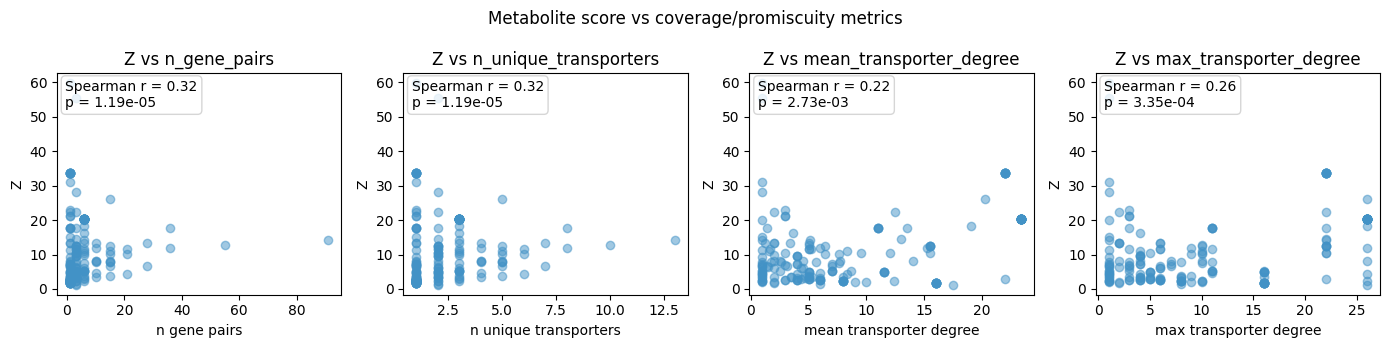

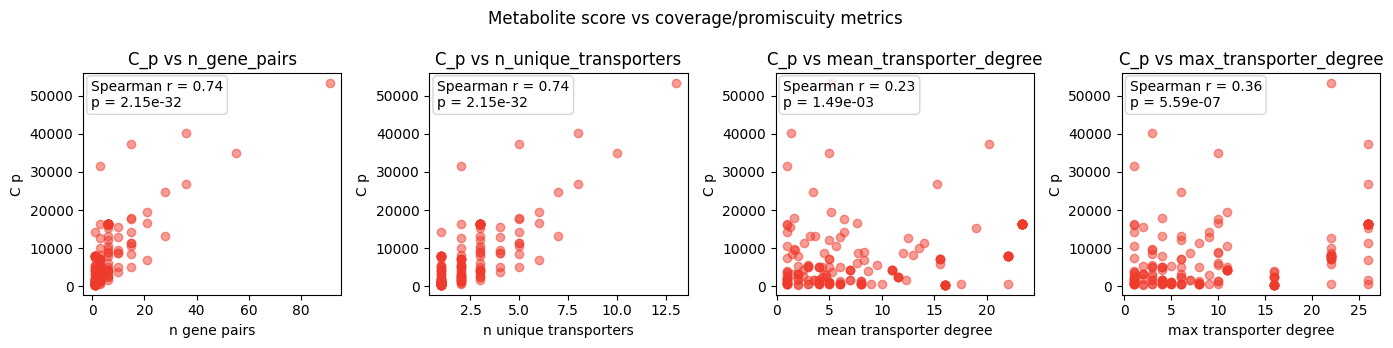

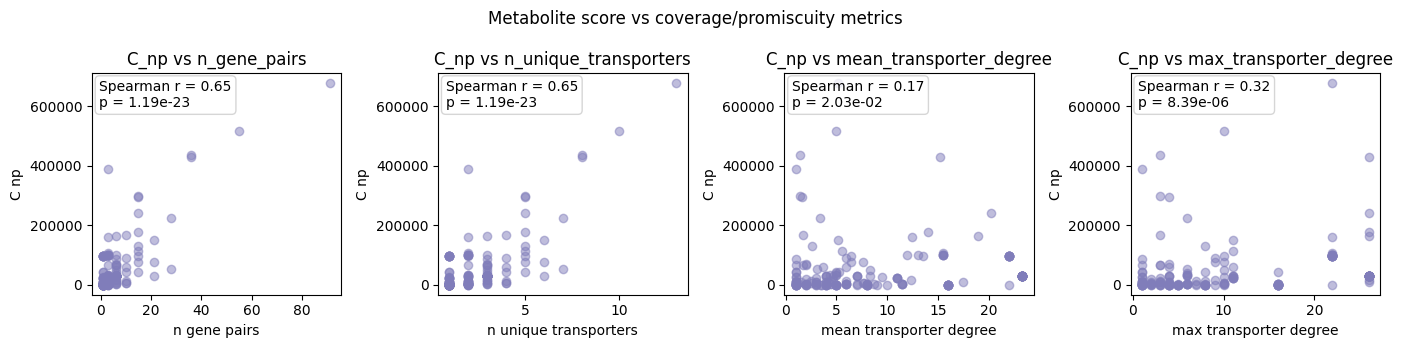

In [84]:
for metric, color in metric_colors.items():
    fig, axes = plot_score_vs_coverage_grid(
        coverage_merged_df,
        y_col=metric,
        x_cols=("n_gene_pairs", "n_unique_transporters", "mean_transporter_degree", "max_transporter_degree"),
        figsize=(14, 3.5),
        remove_yticklabels=False,
        color=color,
        alpha=0.5,
    )
    # fig.savefig(f"{PLOTS_PATH}/{metric}_vs_coverage_metrics_scatter_plot.svg", format="svg", bbox_inches="tight")

In [50]:
res = compute_gene_pair_metab_z_scores(
    adata,
    layer_key_p_test='counts',
    layer_key_np_test='log_norm',
    model="danb",
    exclude_LR=True,
    run_subsampling=True,
    run_leave_one_out=True,
    subsample_k=3,
    subsample_iter=100,
    device='cpu',
)

Running subsampling analysis...


100%|██████████| 100/100 [00:00<00:00, 422.28it/s]


Running leave-one-out analysis...


100%|██████████| 183/183 [00:00<00:00, 7997.89it/s]


(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'Full vs subsampled metabolite scores'}, xlabel='Full metabolite Z-score', ylabel='Subsampled metabolite Z-score'>)

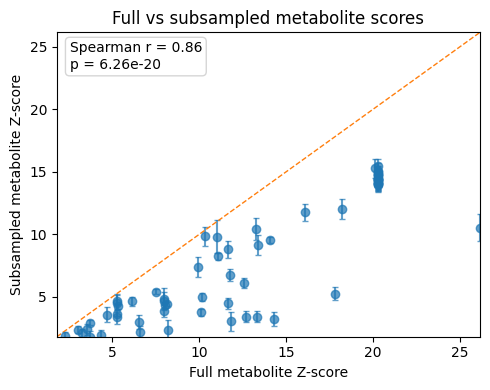

In [51]:
plot_full_vs_subsampled(
    res["subsampling_summary"],
    full_col="full_Z_m",
    subsampled_col="subsampled_mean",
    error_col="subsampled_sem",
    # label_col="metabolite",
    annotate_top_n=10
)

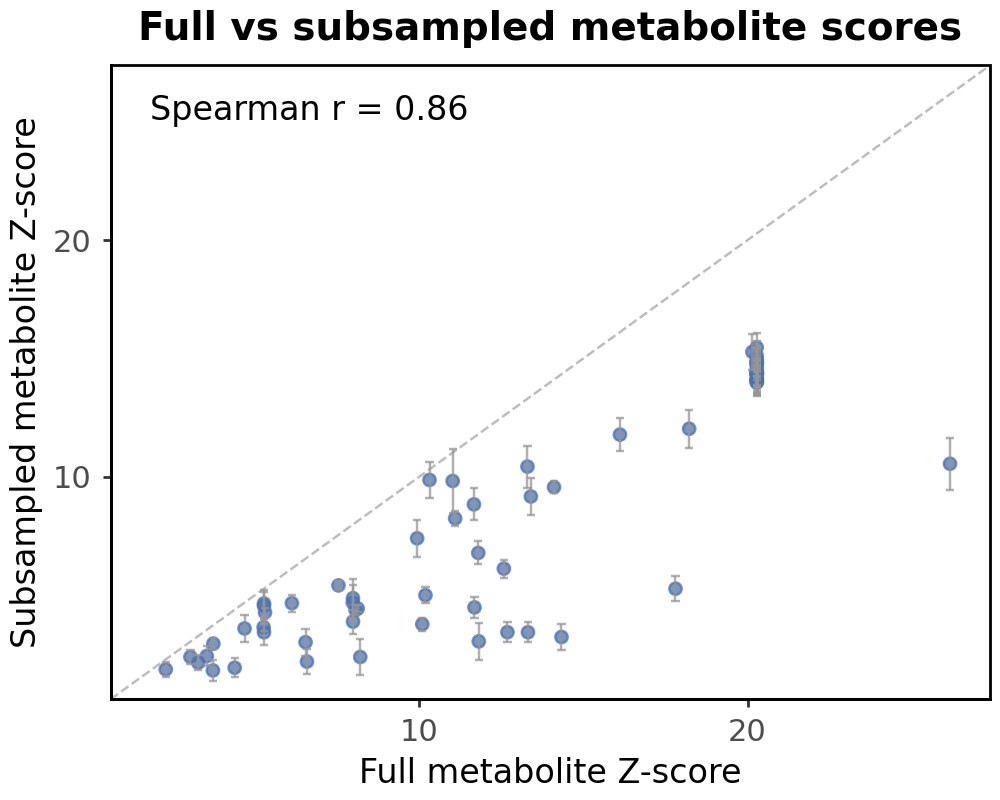

In [80]:
p = plot_full_vs_subsampled_plotnine(
    res["subsampling_summary"],
    full_col="full_Z_m",
    subsampled_col="subsampled_mean",
    error_col="subsampled_sem",
    # label_col="metabolite",
    annotate_top_n=10,
    figure_size=(5,4),
)
p.save(f"{PLOTS_PATH}/full_vs_subsampled_metab_Z_score_scatter_plot.svg")
p.show()

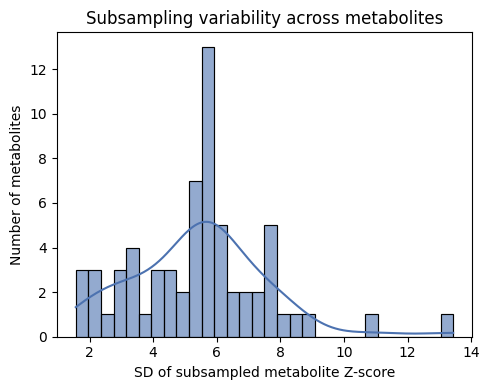

In [81]:
fig, ax = plot_subsampling_variability(res["subsampling_summary"], bins=30)
fig.savefig(f"{PLOTS_PATH}/SD_subsampling_n_metabolites_histplot.svg", format="svg", bbox_inches="tight")

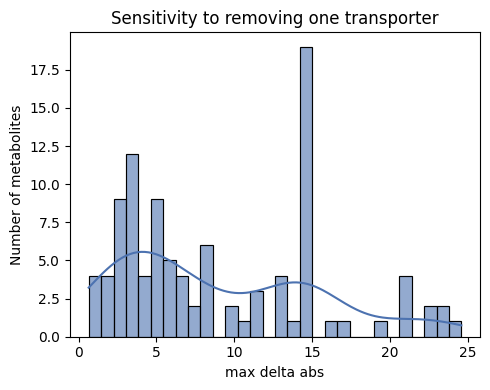

In [86]:
value_col = "max_delta_abs"
fig, ax = plot_leave_one_out_histogram(
    res["leave_one_out_summary"],
    value_col=value_col
)
fig.savefig(f"{PLOTS_PATH}/{value_col}_n_metabolites_histplot.svg", format="svg", bbox_inches="tight")

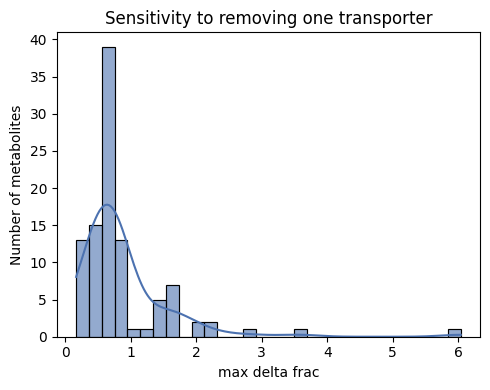

In [83]:
value_col = "max_delta_frac"
fig, ax = plot_leave_one_out_histogram(
    res["leave_one_out_summary"],
    value_col=value_col
)
fig.savefig(f"{PLOTS_PATH}/{value_col}_n_metabolites_histplot.svg", format="svg", bbox_inches="tight")

In [101]:
df = res["leave_one_out_summary"].copy().sort_values(value_col, ascending=False).head(15)

In [103]:
print('\n'.join(df['metabolite'].values))

Folinic acid
Arachidonic acid
GABA
4'-Hydroxydiclofenac
Glutathione
Glucosamine
Docosahexaenoic acid
N-desmethylimatinib
Hydroxylansoprazole
Cortisol
N-Desmethyltamoxifen
Ketone bodies
alpha-Ketoisovaleric acid
D-Lactate
Chloride_bicarbonate anion exchange


In [98]:
res["leave_one_out_summary"]

,metabolite,max_delta_abs,mean_delta_abs,max_delta_frac,mean_delta_frac
0,"(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...",14.535289,8.141503,0.716695,0.401435
1,"1b,3a,12a-Trihydroxy-5b-cholanoic acid",14.535289,8.141503,0.716695,0.401435
2,2-Hydroxychlorpropamide,11.488885,6.265938,0.516122,0.281489
3,3-Sulfodeoxycholic acid,14.535289,8.141503,0.716695,0.401435
4,"3alpha,7alpha-Dihydroxycoprostanic acid",14.535289,8.141503,0.716695,0.401435
...,...,...,...,...,...
96,Vitamin A,9.597283,7.307673,0.716281,0.545399
97,Vitamin D3,3.204073,2.709236,0.510140,0.431354
98,Water,10.508000,3.850202,0.953855,0.349499
99,Zinc,5.071047,2.452373,0.284815,0.137737


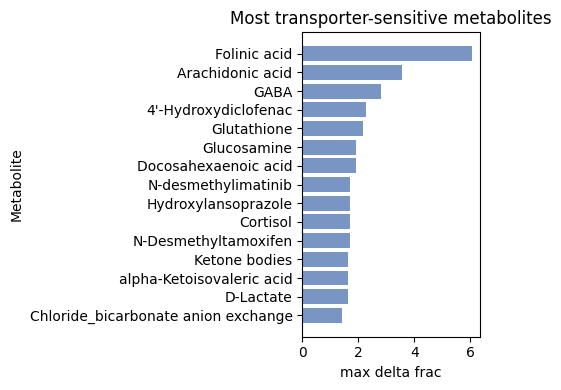

In [96]:
value_col = "max_delta_frac"
top_n=15
fig, ax = plot_top_sensitive_metabolites(
    res["leave_one_out_summary"],
    value_col=value_col,
    top_n=top_n,
    figsize=(5,4)
)
fig.savefig(f"{PLOTS_PATH}/{value_col}_top_{top_n}_most_sensitive_metabolites_barplot.svg", format="svg", bbox_inches="tight")

### Residual dependence after correction

Z

In [104]:
df = coverage_merged_df.copy()
df = df.dropna(subset=["Z", "n_gene_pairs", "mean_transporter_degree"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[["n_gene_pairs", "mean_transporter_degree"]])

X_scaled = pd.DataFrame(X_scaled, columns=["n_gene_pairs", "mean_transporter_degree"])

X_scaled = sm.add_constant(X_scaled)

y = df["Z"]

model = sm.OLS(y, X_scaled).fit()

In [105]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Z   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     18.20
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           6.35e-08
Time:                        16:45:07   Log-Likelihood:                -661.90
No. Observations:                 183   AIC:                             1330.
Df Residuals:                     180   BIC:                             1339.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [123]:
R_sq_df = pd.DataFrame(data={'metric': ['Z', 'C_np', 'C_p'],
                             'adj_R_squared': [0.159, 0.659, 0.659],})
R_sq_df = R_sq_df.iloc[::-1]

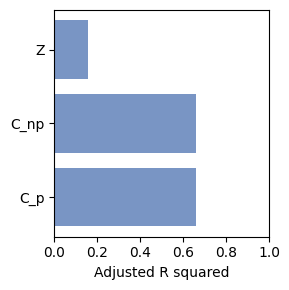

In [128]:
fig, ax = plt.subplots(figsize=(3,3))
ax.barh(R_sq_df['metric'], R_sq_df['adj_R_squared'], color="#4C72B0", alpha=0.75)
ax.set_xlabel("Adjusted R squared")
ax.set_xlim(0,1)
plt.tight_layout()
fig.savefig(f"{PLOTS_PATH}/adj_R_squared_barplot.svg", format="svg", bbox_inches="tight")

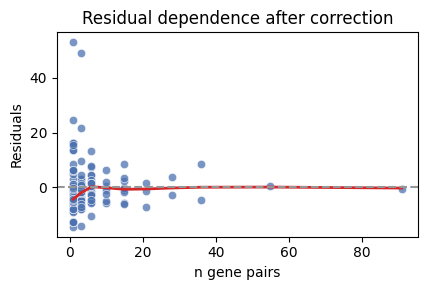

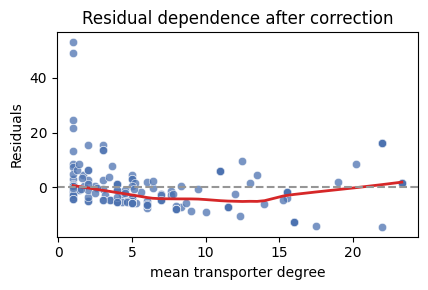

In [130]:
for var in ["n_gene_pairs", "mean_transporter_degree"]:
    fig, ax = plt.subplots(figsize=(4.5,3))
    df["residuals"] = model.resid
    # Scatter
    sns.scatterplot(
        x=df[var],
        y=df["residuals"],
        color="#4C72B0",
        alpha=0.75,
        ax=ax
    )
    # LOWESS curve
    sns.regplot(
        x=df[var],
        y=df["residuals"],
        scatter=False,
        lowess=True,
        color="#D62728",  # red for visibility
        line_kws={"lw": 2},
        ax=ax
    )
    plt.axhline(0, linestyle="--", color='#969696')
    # Labels
    ax.set_xlabel(var.replace("_", " "))
    ax.set_ylabel("Residuals")
    ax.set_title("Residual dependence after correction")
    
    plt.tight_layout()
    plt.show()
    fig.savefig(f"{PLOTS_PATH}/Z_{var}_residuals_scatter_plot.svg", format="svg", bbox_inches="tight")

C_np

In [76]:
df = coverage_merged_df.copy()
df = df.dropna(subset=["Z", "n_gene_pairs", "mean_transporter_degree"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[["n_gene_pairs", "mean_transporter_degree"]])

X_scaled = pd.DataFrame(X_scaled, columns=["n_gene_pairs", "mean_transporter_degree"])

X_scaled = sm.add_constant(X_scaled)

y = df["C_np"]

model = sm.OLS(y, X_scaled).fit()

In [77]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   C_np   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     176.7
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           3.46e-43
Time:                        22:35:17   Log-Likelihood:                -2252.4
No. Observations:                 183   AIC:                             4511.
Df Residuals:                     180   BIC:                             4520.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    4

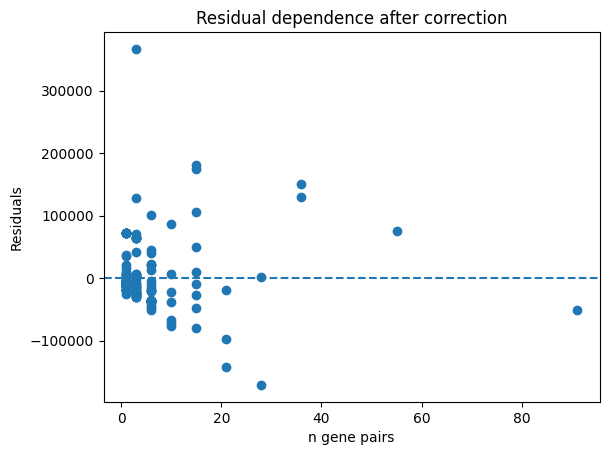

In [78]:
df["residuals"] = model.resid

plt.scatter(df["n_gene_pairs"], df["residuals"])
plt.axhline(0, linestyle="--")
plt.xlabel("n gene pairs")
plt.ylabel("Residuals")
plt.title("Residual dependence after correction")
plt.show()

C_p

In [79]:
df = coverage_merged_df.copy()
df = df.dropna(subset=["Z", "n_gene_pairs", "mean_transporter_degree"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[["n_gene_pairs", "mean_transporter_degree"]])

X_scaled = pd.DataFrame(X_scaled, columns=["n_gene_pairs", "mean_transporter_degree"])

X_scaled = sm.add_constant(X_scaled)

y = df["C_p"]

model = sm.OLS(y, X_scaled).fit()

In [80]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    C_p   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     176.9
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           3.29e-43
Time:                        22:35:34   Log-Likelihood:                -1807.6
No. Observations:                 183   AIC:                             3621.
Df Residuals:                     180   BIC:                             3631.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    7

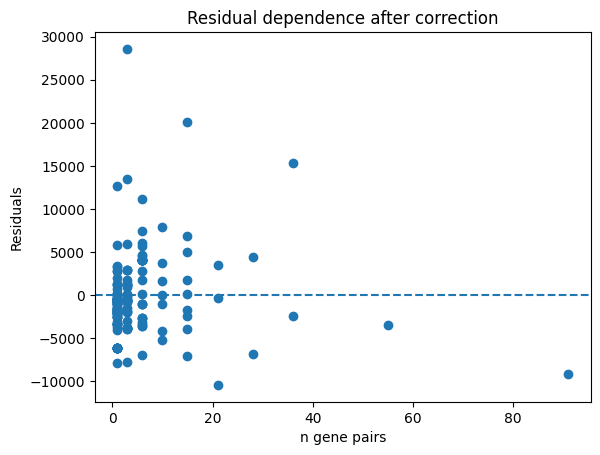

In [81]:
df["residuals"] = model.resid

plt.scatter(df["n_gene_pairs"], df["residuals"])
plt.axhline(0, linestyle="--")
plt.xlabel("n gene pairs")
plt.ylabel("Residuals")
plt.title("Residual dependence after correction")
plt.show()